# 04 — Clasificación ABC/XYZ y dashboard descriptivo

**Objetivo:** Construir la clasificación formal ABC/XYZ del portafolio de ConstruNorte, generar la matriz de 9 segmentos, calcular indicadores descriptivos y producir las visualizaciones para el dashboard de Tableau.

**Fase CRISP-DM:** 5 — Evaluación (componente descriptivo del Tema 1).

**Inputs:**
- Tabla `ventas_semanales` (MySQL) — periodo 2024-2025 únicamente
- Tabla `dim_producto` (MySQL)

**Outputs:**
- Tabla MySQL `clasificacion_abc_xyz` (una fila por SKU activo).
- Archivo `reports/clasificacion_abc_xyz.xlsx` (para entrega a ConstruNorte).
- Visualizaciones guardadas en `reports/figures/abc_xyz/`.
- Insumos directos para el dashboard de Tableau.

**Tema del proyecto:** Este notebook corresponde al **Tema 1 — Análisis descriptivo** del anteproyecto. Es el insumo principal para apoyar las decisiones de **organización de bodega** que tomará ConstruNorte.

**Decisiones técnicas clave:**

1. **Periodo de cálculo:** 2024-01-01 a 2025-12-31 (24 meses completos). No incluimos 2026-Q1 para mantener coherencia con el alcance del anteproyecto.
2. **Doble cálculo de XYZ:** calculamos XYZ sobre serie expandida (con ceros) Y sobre semanas con venta únicamente. Ambas perspectivas se reportan.
3. **SKUs activos únicamente:** solo se clasifican los SKUs activos al cierre del periodo (con venta en los últimos 90 días).
4. **Cortes estándar:** ABC = 80/95/100, XYZ = 0.5/1.0.

**Aclaración importante:** Este equipo entrega un **insumo analítico**. La organización física de la bodega y las decisiones operativas finales corresponden exclusivamente a ConstruNorte.

**Autor:** Equipo del proyecto — Diego Andrés De Jesús Montenegro y Luis David Andrade Díaz
**Fecha:** mayo 2026

In [1]:
# =========================
# Imports
# =========================
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sqlalchemy import text

from src.db import get_engine

# Configuracion visual (paleta del proyecto)
COLOR_PRIMARIO = "#1F4E78"
COLOR_SECUNDARIO = "#E67E22"
COLOR_VERDE = "#27AE60"
COLOR_ROJO = "#C0392B"
COLOR_AMARILLO = "#F1C40F"

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

FIG_DIR = ROOT / "reports" / "figures" / "abc_xyz"
FIG_DIR.mkdir(parents=True, exist_ok=True)

REPORTS_DIR = ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

def guardar(fig, nombre):
    out = FIG_DIR / f"{nombre}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"  Guardado: {out.relative_to(ROOT)}")

print("Setup completado.")

Setup completado.


In [2]:
# =========================
# Constantes del analisis descriptivo
# =========================
# Periodo de calculo (24 meses completos del anteproyecto)
FECHA_INICIO = pd.Timestamp("2024-01-01")
FECHA_FIN = pd.Timestamp("2025-12-31")

# Cortes de clasificacion
CORTE_A = 80   # SKUs A: hasta 80% del valor acumulado
CORTE_B = 95   # SKUs B: del 80% al 95%

CORTE_X = 0.5  # SKUs X: CV <= 0.5
CORTE_Y = 1.0  # SKUs Y: 0.5 < CV <= 1.0

# SKUs activos al cierre
DIAS_PARA_ACTIVO = 90

print(f"Periodo: {FECHA_INICIO.date()} -> {FECHA_FIN.date()} (24 meses)")
print(f"Cortes ABC: <={CORTE_A}% (A) | <={CORTE_B}% (B) | resto (C)")
print(f"Cortes XYZ: <={CORTE_X} (X) | <={CORTE_Y} (Y) | >{CORTE_Y} (Z)")

Periodo: 2024-01-01 -> 2025-12-31 (24 meses)
Cortes ABC: <=80% (A) | <=95% (B) | resto (C)
Cortes XYZ: <=0.5 (X) | <=1.0 (Y) | >1.0 (Z)


## 1. Carga de datos del periodo 2024-2025

In [3]:
engine = get_engine()

# Cargar ventas semanales SOLO del periodo 2024-2025 (no incluimos test 2026)
ventas = pd.read_sql(
    text("""
        SELECT * FROM ventas_semanales
        WHERE fecha_inicio_semana BETWEEN :inicio AND :fin
    """),
    engine,
    params={"inicio": FECHA_INICIO, "fin": FECHA_FIN},
    parse_dates=["fecha_inicio_semana"],
)

dim_producto = pd.read_sql(
    "SELECT * FROM dim_producto",
    engine,
    parse_dates=["fecha_primera_venta", "fecha_ultima_venta"],
)

print(f"ventas (2024-2025): {len(ventas):>10,} filas")
print(f"dim_producto:       {len(dim_producto):>10,} SKUs totales")

ventas (2024-2025):    162,289 filas
dim_producto:            4,282 SKUs totales


In [4]:
# Filtrar a SKUs activos al cierre del periodo (mismo criterio que notebook 03)
fecha_corte_activo = FECHA_FIN - pd.Timedelta(days=DIAS_PARA_ACTIVO)
skus_activos = (
    ventas[ventas["fecha_inicio_semana"] >= fecha_corte_activo]
    ["item"].unique()
)

ventas_act = ventas[ventas["item"].isin(skus_activos)].copy()

print(f"Fecha corte para 'activo': {fecha_corte_activo.date()}")
print(f"SKUs activos al cierre 2025: {len(skus_activos):>6,}")
print(f"Filas tras filtrar:          {len(ventas_act):>6,}")

Fecha corte para 'activo': 2025-10-02
SKUs activos al cierre 2025:  2,380
Filas tras filtrar:          149,400


## 2. Clasificación ABC (Pareto formal)

Agrupamos por SKU, sumamos el valor total comercializado en el periodo y aplicamos los cortes 80/95/100.

In [5]:
# Sumar valor total por SKU
valor_por_sku = (
    ventas_act.groupby("item")
    .agg(
        valor_total=("valor_bruto_total", "sum"),
        cantidad_total=("cantidad_total", "sum"),
        num_semanas_con_venta=("fecha_inicio_semana", "nunique"),
    )
    .sort_values("valor_total", ascending=False)
    .reset_index()
)

# Calcular porcentaje acumulado
valor_total_global = valor_por_sku["valor_total"].sum()
valor_por_sku["porcentaje"] = valor_por_sku["valor_total"] / valor_total_global * 100
valor_por_sku["porcentaje_acumulado"] = valor_por_sku["porcentaje"].cumsum()

# Asignar clase ABC
def clasificar_abc(pct_acum):
    if pct_acum <= CORTE_A:
        return "A"
    elif pct_acum <= CORTE_B:
        return "B"
    else:
        return "C"

valor_por_sku["clase_abc"] = valor_por_sku["porcentaje_acumulado"].apply(clasificar_abc)

# Resumen
print("Distribucion ABC:")
print(valor_por_sku["clase_abc"].value_counts().sort_index())
print()
print("Valor por clase:")
print(valor_por_sku.groupby("clase_abc")["valor_total"]
      .sum().apply(lambda x: f"${x:,.0f}"))
print()
print("Porcentaje del valor por clase:")
print(valor_por_sku.groupby("clase_abc")["porcentaje"].sum().apply(lambda x: f"{x:.2f}%"))

Distribucion ABC:
clase_abc
A      97
B     365
C    1918
Name: count, dtype: int64

Valor por clase:
clase_abc
A    $100,913,761,008
B     $19,067,914,249
C      $6,316,906,034
Name: valor_total, dtype: object

Porcentaje del valor por clase:
clase_abc
A    79.90%
B    15.10%
C     5.00%
Name: porcentaje, dtype: object


In [6]:
# Vistazo a los top SKUs (clase A)
top_a = (
    valor_por_sku[valor_por_sku["clase_abc"] == "A"]
    .merge(dim_producto[["item", "nombre_item", "nombre_linea_n1"]], on="item", how="left")
    [["item", "nombre_item", "nombre_linea_n1", "valor_total", "porcentaje_acumulado"]]
)
print(f"Top SKUs clase A ({len(top_a)} en total):")
top_a.head(15)

Top SKUs clase A (97 en total):


,item,nombre_item,nombre_linea_n1,valor_total,porcentaje_acumulado
0,000041,CEMENTO GRIS *50 KL T1 ARGOS,CEMENTOS,"28,196,379,716.0000",22.3252
1,000291,VARILLA CORR 1/2 * 6 MTS,ACEROS,"9,041,477,207.0000",29.4840
2,000289,VARILLA CORR 3/8 * 6 MTS,ACEROS,"6,193,325,416.0000",34.3877
3,009511,SUR CEMENTO ARGOS T1,CEMENTOS,"3,260,097,586.0000",36.9690
4,000255,HIERRO DE 1/4 *KG P/FLEJES,ACEROS,"3,209,687,304.0000",39.5103
5,010213,T1 CEMENTO GRIS * 50KG RETIRADO EN PLANT,CEMENTOS,"2,917,931,206.0000",41.8207
6,000292,VARILLA CORR 5/8 * 6 MTS,ACEROS,"2,683,900,730.0000",43.9457
7,000551,TEJA PROTEJA P7 6 (1.80),CUBIERTAS,"2,077,059,192.0000",45.5903
8,000539,PLACA PANEL YESO GYPLAC (1/2 ),CONSTRUCCION LIVIANA,"1,691,227,449.0000",46.9293
9,000548,TEJA PROTEJA P7 10(3.05),CUBIERTAS,"1,593,745,009.0000",48.1912


## 3. Clasificación XYZ-A (sobre serie expandida con ceros)

Mide la variabilidad de la demanda **considerando todas las semanas** (incluyendo las que no hubo venta). Es la perspectiva tradicional de gestión de inventarios.

In [7]:
# Construir el calendario completo de semanas del periodo
semanas_grid = pd.date_range(start=FECHA_INICIO, end=FECHA_FIN, freq="W-MON")
print(f"Semanas totales en el periodo: {len(semanas_grid)}")

# Para cada SKU, agregar cantidad por semana (sumando los 3 centros si los hay)
ventas_agregado_sku = (
    ventas_act.groupby(["item", "fecha_inicio_semana"])["cantidad_total"]
    .sum()
    .reset_index()
)
print(f"Filas agregadas por SKU x semana: {len(ventas_agregado_sku):,}")

Semanas totales en el periodo: 105
Filas agregadas por SKU x semana: 101,621


In [8]:
# Calcular CV expandido (rellenando con ceros las semanas sin venta)
# Para cada SKU, expandimos a todas las semanas del periodo desde su primera venta
primeras_ventas = ventas_agregado_sku.groupby("item")["fecha_inicio_semana"].min().to_dict()

cv_expandido = []
for item, primera in primeras_ventas.items():
    # Serie con todas las semanas desde la primera venta
    serie_completa = pd.DataFrame({
        "fecha_inicio_semana": semanas_grid[semanas_grid >= primera]
    })
    serie_completa["item"] = item

    # Merge con las ventas reales
    serie_real = ventas_agregado_sku[ventas_agregado_sku["item"] == item]
    serie_completa = serie_completa.merge(
        serie_real[["fecha_inicio_semana", "cantidad_total"]],
        on="fecha_inicio_semana", how="left"
    )
    serie_completa["cantidad_total"] = serie_completa["cantidad_total"].fillna(0)

    media = serie_completa["cantidad_total"].mean()
    desv = serie_completa["cantidad_total"].std()
    cv = desv / media if media > 0 else 99
    cv_expandido.append({
        "item": item,
        "cv_expandido": cv,
        "promedio_semanal_expandido": media,
        "num_semanas_expandido": len(serie_completa),
    })

cv_expandido_df = pd.DataFrame(cv_expandido)

# Asignar clase XYZ-A
def clasificar_xyz(cv):
    if cv <= CORTE_X:
        return "X"
    elif cv <= CORTE_Y:
        return "Y"
    else:
        return "Z"

cv_expandido_df["clase_xyz_expandida"] = cv_expandido_df["cv_expandido"].apply(clasificar_xyz)

print("Distribucion XYZ-A (serie expandida con ceros):")
print(cv_expandido_df["clase_xyz_expandida"].value_counts().sort_index())

Distribucion XYZ-A (serie expandida con ceros):
clase_xyz_expandida
X      27
Y     318
Z    2035
Name: count, dtype: int64


## 4. Clasificación XYZ-B (solo semanas con venta)

Mide la variabilidad **condicional a que el producto se vendió**. Ignora los ceros. Útil para responder: "cuando este producto se vende, ¿es regular o variable?".

In [9]:
# CV solo sobre semanas con venta
cv_venta = (
    ventas_agregado_sku
    .groupby("item")
    .agg(
        promedio_semanal_venta=("cantidad_total", "mean"),
        desv_semanal_venta=("cantidad_total", "std"),
        num_semanas_con_venta=("fecha_inicio_semana", "nunique"),
    )
    .reset_index()
)

cv_venta["cv_venta"] = cv_venta["desv_semanal_venta"] / cv_venta["promedio_semanal_venta"]
cv_venta["cv_venta"] = cv_venta["cv_venta"].fillna(0)

# SKUs con muy pocas semanas (<5) se marcan como Z (no hay suficiente historia)
cv_venta.loc[cv_venta["num_semanas_con_venta"] < 5, "cv_venta"] = 99

cv_venta["clase_xyz_venta"] = cv_venta["cv_venta"].apply(clasificar_xyz)

print("Distribucion XYZ-B (solo semanas con venta):")
print(cv_venta["clase_xyz_venta"].value_counts().sort_index())

Distribucion XYZ-B (solo semanas con venta):
clase_xyz_venta
X     285
Y     990
Z    1105
Name: count, dtype: int64


## 5. Matriz combinada ABC × XYZ (9 segmentos)

Cruzamos las clasificaciones para obtener una caracterización completa del portafolio.

In [10]:
# Construir tabla final combinada
clasificacion = (
    valor_por_sku
    .merge(cv_expandido_df, on="item", how="left")
    .merge(cv_venta[["item", "cv_venta", "promedio_semanal_venta",
                     "num_semanas_con_venta", "clase_xyz_venta"]],
           on="item", how="left", suffixes=("", "_venta"))
)

# Segmento combinado (usamos XYZ-A como version oficial)
clasificacion["segmento_abc_xyz"] = (
    clasificacion["clase_abc"] + clasificacion["clase_xyz_expandida"]
)

# Agregar info del producto
clasificacion = clasificacion.merge(
    dim_producto[["item", "nombre_item", "nombre_linea_n1", "nombre_linea_n2",
                   "proveedor_codigo", "proveedor_nombre"]],
    on="item", how="left"
)

print(f"Tabla de clasificacion construida: {len(clasificacion):,} SKUs")
print(f"\nDistribucion por segmento ABC x XYZ (expandido):")
print(clasificacion["segmento_abc_xyz"].value_counts().sort_index())

Tabla de clasificacion construida: 2,380 SKUs

Distribucion por segmento ABC x XYZ (expandido):
segmento_abc_xyz
AX       4
AY      47
AZ      46
BX      16
BY     105
BZ     244
CX       7
CY     166
CZ    1745
Name: count, dtype: int64


In [11]:
# Vista de la matriz como tabla cruzada
matriz_conteo = pd.crosstab(
    clasificacion["clase_abc"],
    clasificacion["clase_xyz_expandida"],
    margins=True, margins_name="Total"
)
print("Matriz de conteo de SKUs (filas: ABC, columnas: XYZ expandido):")
matriz_conteo

Matriz de conteo de SKUs (filas: ABC, columnas: XYZ expandido):


clase_xyz_expandida,X,Y,Z,Total
clase_abc,,,,
A,4,47,46,97
B,16,105,244,365
C,7,166,1745,1918
Total,27,318,2035,2380


In [12]:
# Matriz de valor total por segmento (millones COP)
matriz_valor = pd.crosstab(
    clasificacion["clase_abc"],
    clasificacion["clase_xyz_expandida"],
    values=clasificacion["valor_total"] / 1_000_000,
    aggfunc="sum",
    margins=True, margins_name="Total"
).round(0)
print("Matriz de valor total por segmento (millones COP):")
matriz_valor

Matriz de valor total por segmento (millones COP):


clase_xyz_expandida,X,Y,Z,Total
clase_abc,,,,
A,"30,197.0000","52,802.0000","17,916.0000","100,914.0000"
B,920.0000,"5,544.0000","12,604.0000","19,068.0000"
C,70.0000,"1,209.0000","5,038.0000","6,317.0000"
Total,"31,186.0000","59,554.0000","35,558.0000","126,299.0000"


## 6. Indicadores descriptivos clave

In [13]:
# KPIs principales
n_skus = len(clasificacion)
valor_total_periodo = clasificacion["valor_total"].sum()

skus_a = (clasificacion["clase_abc"] == "A").sum()
valor_a = clasificacion[clasificacion["clase_abc"] == "A"]["valor_total"].sum()

cv_promedio = clasificacion["cv_expandido"].replace(99, np.nan).mean()
skus_segmento_cz = (clasificacion["segmento_abc_xyz"] == "CZ").sum()

print("=" * 60)
print("INDICADORES DESCRIPTIVOS — CONSTRUNORTE 2024-2025")
print("=" * 60)
print(f"SKUs activos analizados:        {n_skus:>10,}")
print(f"Valor total comercializado:     ${valor_total_periodo:>15,.0f}")
print()
print(f"SKUs clase A:                   {skus_a:>10,} ({skus_a / n_skus * 100:.2f}% del portafolio)")
print(f"Valor concentrado en clase A:   ${valor_a:>15,.0f} ({valor_a / valor_total_periodo * 100:.2f}%)")
print()
print(f"Coeficiente de variacion promedio: {cv_promedio:.2f}")
print(f"SKUs en segmento CZ (revisar):     {skus_segmento_cz:>10,}")
print("=" * 60)

INDICADORES DESCRIPTIVOS — CONSTRUNORTE 2024-2025
SKUs activos analizados:             2,380
Valor total comercializado:     $126,298,581,291

SKUs clase A:                           97 (4.08% del portafolio)
Valor concentrado en clase A:   $100,913,761,008 (79.90%)

Coeficiente de variacion promedio: 2.22
SKUs en segmento CZ (revisar):          1,745


## 7. Visualización — Curva de Pareto formal

  Guardado: reports/figures/abc_xyz/01_pareto_formal.png


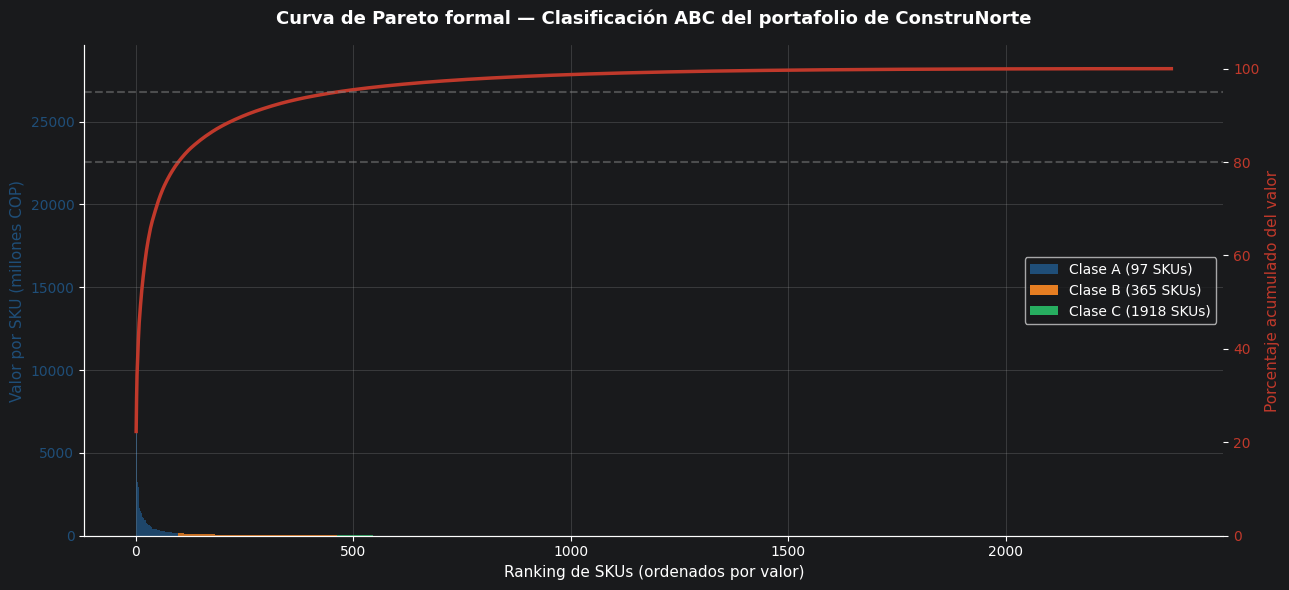

In [14]:
# Pareto con cortes A/B/C marcados
fig, ax1 = plt.subplots(figsize=(13, 6))

x = np.arange(1, len(clasificacion) + 1)
clasificacion_ord = clasificacion.sort_values("valor_total", ascending=False).reset_index(drop=True)

# Colorear por clase
colores_clase = clasificacion_ord["clase_abc"].map({
    "A": COLOR_PRIMARIO, "B": COLOR_SECUNDARIO, "C": COLOR_VERDE
})

ax1.bar(x, clasificacion_ord["valor_total"] / 1_000_000,
        color=colores_clase, width=1.0, edgecolor="none", alpha=0.85)
ax1.set_xlabel("Ranking de SKUs (ordenados por valor)")
ax1.set_ylabel("Valor por SKU (millones COP)", color=COLOR_PRIMARIO)
ax1.tick_params(axis="y", labelcolor=COLOR_PRIMARIO)

# Linea acumulada
ax2 = ax1.twinx()
pct_acum = clasificacion_ord["valor_total"].cumsum() / clasificacion_ord["valor_total"].sum() * 100
ax2.plot(x, pct_acum, color=COLOR_ROJO, linewidth=2.5, label="% acumulado")
ax2.set_ylabel("Porcentaje acumulado del valor", color=COLOR_ROJO)
ax2.tick_params(axis="y", labelcolor=COLOR_ROJO)
ax2.set_ylim(0, 105)
ax2.axhline(80, color="gray", linestyle="--", alpha=0.5)
ax2.axhline(95, color="gray", linestyle="--", alpha=0.5)
ax2.grid(False)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_PRIMARIO, label=f"Clase A ({skus_a} SKUs)"),
    Patch(facecolor=COLOR_SECUNDARIO, label=f"Clase B ({(clasificacion['clase_abc'] == 'B').sum()} SKUs)"),
    Patch(facecolor=COLOR_VERDE, label=f"Clase C ({(clasificacion['clase_abc'] == 'C').sum()} SKUs)"),
]
ax1.legend(handles=legend_elements, loc="center right")

plt.title("Curva de Pareto formal — Clasificación ABC del portafolio de ConstruNorte", pad=15)
plt.tight_layout()
guardar(fig, "01_pareto_formal")
plt.show()

## 8. Visualización — Heatmap de la matriz ABC × XYZ

  Guardado: reports/figures/abc_xyz/02_heatmap_matriz_abc_xyz.png


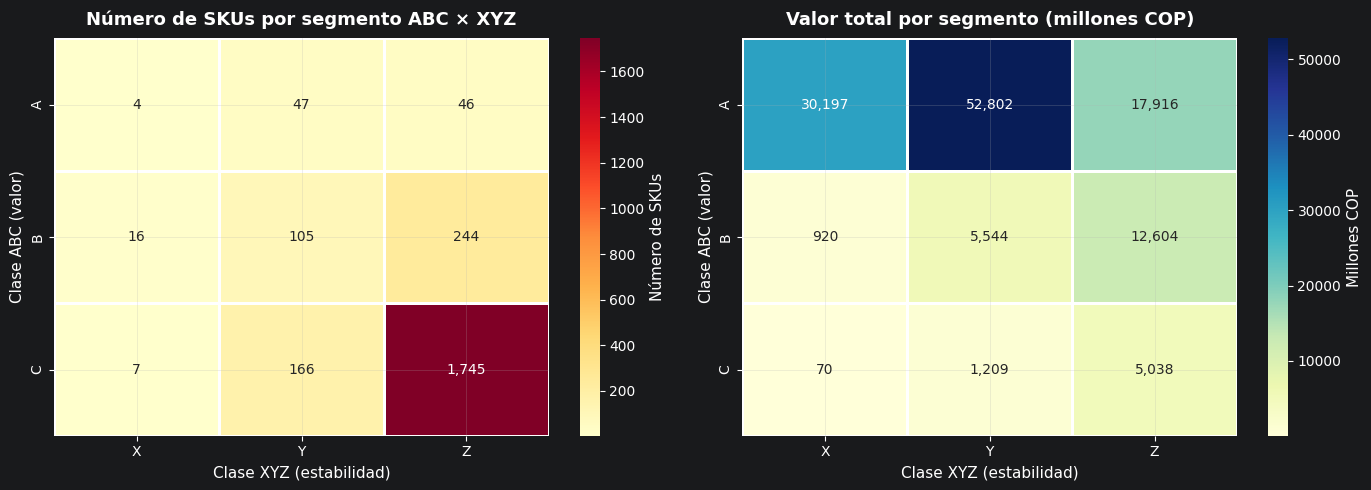

In [15]:
# Preparar datos para heatmap (sin la fila/columna "Total")
matriz_conteo_plot = pd.crosstab(
    clasificacion["clase_abc"],
    clasificacion["clase_xyz_expandida"],
).reindex(index=["A", "B", "C"], columns=["X", "Y", "Z"], fill_value=0)

matriz_valor_plot = pd.crosstab(
    clasificacion["clase_abc"],
    clasificacion["clase_xyz_expandida"],
    values=clasificacion["valor_total"] / 1_000_000,
    aggfunc="sum",
).reindex(index=["A", "B", "C"], columns=["X", "Y", "Z"], fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de conteo
sns.heatmap(matriz_conteo_plot, annot=True, fmt=",d", cmap="YlOrRd",
            ax=axes[0], cbar_kws={"label": "Número de SKUs"}, linewidths=1)
axes[0].set_title("Número de SKUs por segmento ABC × XYZ", pad=10)
axes[0].set_xlabel("Clase XYZ (estabilidad)")
axes[0].set_ylabel("Clase ABC (valor)")

# Heatmap de valor
sns.heatmap(matriz_valor_plot, annot=True, fmt=",.0f", cmap="YlGnBu",
            ax=axes[1], cbar_kws={"label": "Millones COP"}, linewidths=1)
axes[1].set_title("Valor total por segmento (millones COP)", pad=10)
axes[1].set_xlabel("Clase XYZ (estabilidad)")
axes[1].set_ylabel("Clase ABC (valor)")

plt.tight_layout()
guardar(fig, "02_heatmap_matriz_abc_xyz")
plt.show()

## 9. Visualización — Distribución de clases por línea de producto

  Guardado: reports/figures/abc_xyz/03_distribucion_lineas_abc.png


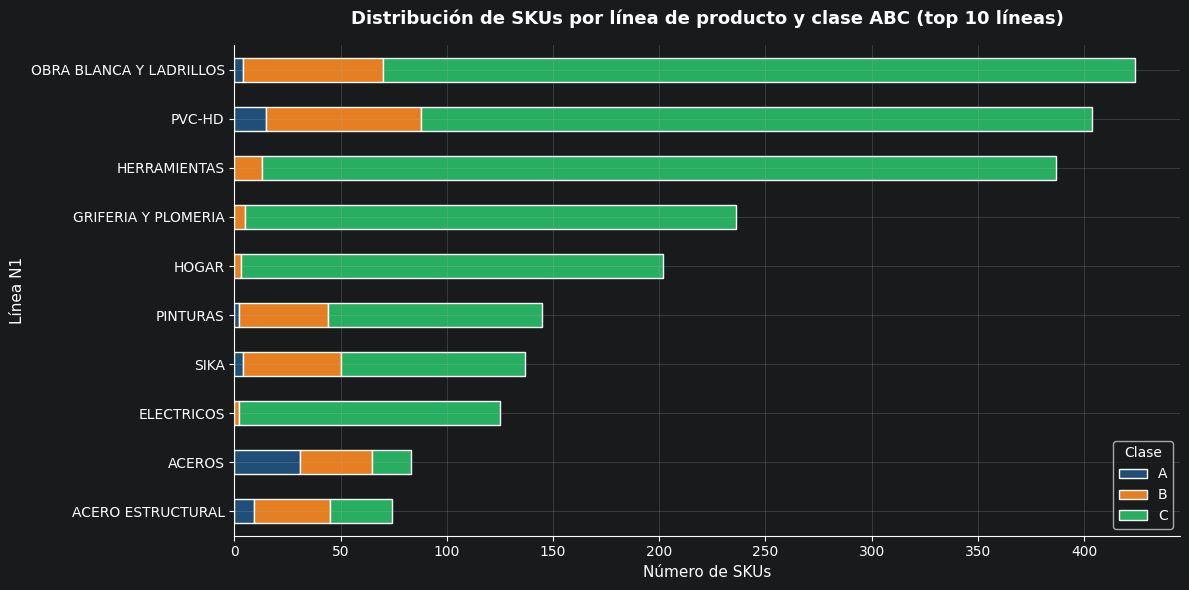

In [16]:
# Distribucion de SKUs por linea N1 y clase ABC
top_lineas = clasificacion["nombre_linea_n1"].value_counts().head(10).index
df_linea = clasificacion[clasificacion["nombre_linea_n1"].isin(top_lineas)]

matriz_linea = pd.crosstab(
    df_linea["nombre_linea_n1"],
    df_linea["clase_abc"],
).reindex(columns=["A", "B", "C"], fill_value=0)
matriz_linea = matriz_linea.loc[matriz_linea.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(12, 6))
matriz_linea.plot(
    kind="barh", stacked=True, ax=ax,
    color=[COLOR_PRIMARIO, COLOR_SECUNDARIO, COLOR_VERDE], edgecolor="white",
)
ax.set_title("Distribución de SKUs por línea de producto y clase ABC (top 10 líneas)", pad=15)
ax.set_xlabel("Número de SKUs")
ax.set_ylabel("Línea N1")
ax.legend(title="Clase", loc="lower right")
plt.tight_layout()
guardar(fig, "03_distribucion_lineas_abc")
plt.show()

## 10. Visualización — Top 20 SKUs clase A

  Guardado: reports/figures/abc_xyz/04_top20_clase_a.png


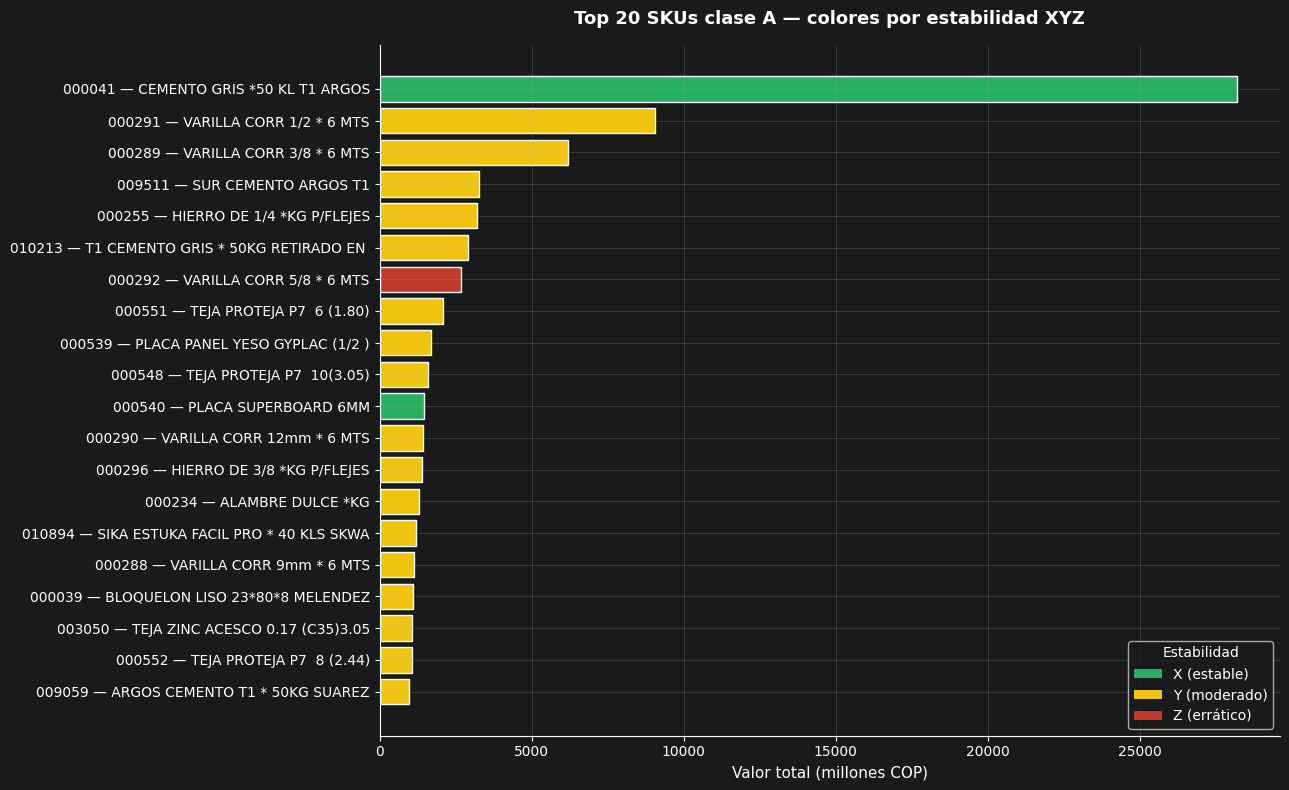

In [17]:
# Top 20 SKUs clase A
top20_a = (
    clasificacion[clasificacion["clase_abc"] == "A"]
    .sort_values("valor_total", ascending=False)
    .head(20)
    .copy()
)
top20_a["etiqueta"] = top20_a["item"] + " — " + top20_a["nombre_item"].str[:35]

# Colorear por clase XYZ
color_xyz = {"X": COLOR_VERDE, "Y": COLOR_AMARILLO, "Z": COLOR_ROJO}
colores = top20_a["clase_xyz_expandida"].map(color_xyz)

fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(top20_a["etiqueta"][::-1], top20_a["valor_total"][::-1] / 1_000_000,
        color=colores[::-1], edgecolor="white")
ax.set_title("Top 20 SKUs clase A — colores por estabilidad XYZ", pad=15)
ax.set_xlabel("Valor total (millones COP)")

legend_xyz = [
    Patch(facecolor=COLOR_VERDE, label="X (estable)"),
    Patch(facecolor=COLOR_AMARILLO, label="Y (moderado)"),
    Patch(facecolor=COLOR_ROJO, label="Z (errático)"),
]
ax.legend(handles=legend_xyz, loc="lower right", title="Estabilidad")
plt.tight_layout()
guardar(fig, "04_top20_clase_a")
plt.show()

## 11. Análisis del segmento CZ

SKUs con bajo valor y demanda errática. Son candidatos a **revisión** por parte de la organización (no a eliminación automática — eso es decisión de ConstruNorte).

In [18]:
# SKUs en segmento CZ
skus_cz = (
    clasificacion[clasificacion["segmento_abc_xyz"] == "CZ"]
    .sort_values("valor_total", ascending=False)
    .head(30)
    [["item", "nombre_item", "nombre_linea_n1", "valor_total",
      "num_semanas_con_venta", "cv_expandido"]]
)
total_cz = (clasificacion["segmento_abc_xyz"] == "CZ").sum()
print(f"Total SKUs en segmento CZ: {total_cz}")
print(f"Top 30 mostrados (ordenados por valor):")
skus_cz

Total SKUs en segmento CZ: 1745
Top 30 mostrados (ordenados por valor):


,item,nombre_item,nombre_linea_n1,valor_total,num_semanas_con_venta,cv_expandido
462,005077,TEJA POLICARB OPALIZ 6 (1.80) AJOVER,CUBIERTAS,"18,199,971.0000",69,1.2532
465,003852,TUBO BIAX 8 PR160 * 6 MTS PAVCO,PVC-HD,"17,905,551.0000",2,1.9685
467,008159,PORCELANATO BLANCO POLAR J20600 60*60,OBRA BLANCA Y LADRILLOS,"17,822,690.0000",52,2.9180
469,000492,MTS TUBO VENT 2 FINO PAVCO,PVC-HD,"17,610,245.0000",55,2.0655
471,004349,GRICOL MEZ DUCHA ATLANTICO,GRIFERIA Y PLOMERIA,"17,228,530.0000",63,1.3761
472,000274,PUNTILLA CC*800gr 5,ACEROS,"17,174,999.0000",93,1.1324
473,009648,ALFA MADERA TAMPA ALMENDRA 24 90(1.30),OBRA BLANCA Y LADRILLOS,"17,160,359.0000",9,5.7983
475,005991,ALFA TABLON LT/ROJO 20*20 1M,OBRA BLANCA Y LADRILLOS,"16,811,762.0000",53,2.7360
478,002738,BASE DEEP VINILTEX GALON TIPO 1,PINTURAS,"16,496,597.0000",83,1.0048
479,001899,UNION RAPID DESLI UM 3 PAVCO,PVC-HD,"16,426,805.0000",73,1.5050


## 12. Análisis de SKUs estrella (segmento AX y AY)

SKUs de alto valor Y demanda estable. Son los productos críticos del negocio.

In [19]:
# SKUs en segmento AX o AY
skus_estrella = (
    clasificacion[clasificacion["segmento_abc_xyz"].isin(["AX", "AY"])]
    .sort_values("valor_total", ascending=False)
    [["item", "nombre_item", "nombre_linea_n1", "valor_total",
      "segmento_abc_xyz", "num_semanas_con_venta", "cv_expandido"]]
)
print(f"Total SKUs en segmentos AX/AY: {len(skus_estrella)}")
if len(skus_estrella) > 0:
    print(skus_estrella.head(15))
else:
    print("\nNota: si hay 0 SKUs en AX/AY es porque el CV expandido tiende a ser alto")
    print("en ferreteria. Revisar tambien clase_xyz_venta para complementar.")

Total SKUs en segmentos AX/AY: 51
      item                               nombre_item       nombre_linea_n1  \
0   000041              CEMENTO GRIS *50 KL T1 ARGOS              CEMENTOS   
1   000291                  VARILLA CORR 1/2 * 6 MTS                ACEROS   
2   000289                  VARILLA CORR 3/8 * 6 MTS                ACEROS   
3   009511                      SUR CEMENTO ARGOS T1              CEMENTOS   
4   000255                HIERRO DE 1/4 *KG P/FLEJES                ACEROS   
5   010213  T1 CEMENTO GRIS * 50KG RETIRADO EN PLANT              CEMENTOS   
7   000551                 TEJA PROTEJA P7  6 (1.80)             CUBIERTAS   
8   000539            PLACA PANEL YESO GYPLAC (1/2 )  CONSTRUCCION LIVIANA   
9   000548                 TEJA PROTEJA P7  10(3.05)             CUBIERTAS   
10  000540                      PLACA SUPERBOARD 6MM  CONSTRUCCION LIVIANA   
11  000290                 VARILLA CORR 12mm * 6 MTS                ACEROS   
12  000296                HIER

In [20]:
# Mismo analisis pero usando clase_xyz_venta (sin ceros)
clasificacion["segmento_xyz_venta"] = (
    clasificacion["clase_abc"] + clasificacion["clase_xyz_venta"]
)
print("Distribucion alternativa usando XYZ-B (solo semanas con venta):")
print(clasificacion["segmento_xyz_venta"].value_counts().sort_index())

print("\nSKUs estrella segun XYZ-B:")
estrella_b = clasificacion[clasificacion["segmento_xyz_venta"].isin(["AX", "AY"])]
print(f"Total: {len(estrella_b)}")
estrella_b.head(15)[["item", "nombre_item", "valor_total",
                     "segmento_xyz_venta", "cv_venta"]]

Distribucion alternativa usando XYZ-B (solo semanas con venta):
segmento_xyz_venta
AX      5
AY     59
AZ     33
BX     19
BY    179
BZ    167
CX    261
CY    752
CZ    905
Name: count, dtype: int64

SKUs estrella segun XYZ-B:
Total: 64


,item,nombre_item,valor_total,segmento_xyz_venta,cv_venta
0,000041,CEMENTO GRIS *50 KL T1 ARGOS,"28,196,379,716.0000",AX,0.4957
1,000291,VARILLA CORR 1/2 * 6 MTS,"9,041,477,207.0000",AY,0.5848
2,000289,VARILLA CORR 3/8 * 6 MTS,"6,193,325,416.0000",AY,0.5427
3,009511,SUR CEMENTO ARGOS T1,"3,260,097,586.0000",AY,0.5590
4,000255,HIERRO DE 1/4 *KG P/FLEJES,"3,209,687,304.0000",AY,0.6124
5,010213,T1 CEMENTO GRIS * 50KG RETIRADO EN PLANT,"2,917,931,206.0000",AY,0.6817
7,000551,TEJA PROTEJA P7 6 (1.80),"2,077,059,192.0000",AY,0.8871
8,000539,PLACA PANEL YESO GYPLAC (1/2 ),"1,691,227,449.0000",AY,0.5236
9,000548,TEJA PROTEJA P7 10(3.05),"1,593,745,009.0000",AY,0.7285
10,000540,PLACA SUPERBOARD 6MM,"1,472,695,193.0000",AX,0.4673


## 13. Guardado a MySQL y exportación a Excel

In [21]:
# Preparar tabla final para guardar
columnas_finales = [
    "item", "nombre_item", "nombre_linea_n1", "nombre_linea_n2",
    "proveedor_codigo", "proveedor_nombre",
    "valor_total", "cantidad_total", "porcentaje", "porcentaje_acumulado",
    "num_semanas_con_venta",
    "promedio_semanal_expandido", "cv_expandido", "clase_xyz_expandida",
    "promedio_semanal_venta", "cv_venta", "clase_xyz_venta",
    "clase_abc", "segmento_abc_xyz", "segmento_xyz_venta",
]

clasif_final = clasificacion[columnas_finales].copy()
print(f"Tabla final: {len(clasif_final):,} filas x {len(clasif_final.columns)} columnas")

Tabla final: 2,380 filas x 20 columnas


In [22]:
# Guardar en MySQL
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS clasificacion_abc_xyz"))

clasif_final.to_sql(
    "clasificacion_abc_xyz",
    engine,
    if_exists="replace",
    index=False,
    method="multi",
    chunksize=1000,
)

with engine.connect() as conn:
    n = conn.execute(text("SELECT COUNT(*) FROM clasificacion_abc_xyz")).scalar()
print(f"Tabla clasificacion_abc_xyz cargada: {n:,} filas")

Tabla clasificacion_abc_xyz cargada: 2,380 filas


In [23]:
# Exportar a Excel (para entrega a ConstruNorte)
ruta_excel = REPORTS_DIR / "clasificacion_abc_xyz.xlsx"

with pd.ExcelWriter(ruta_excel, engine="openpyxl") as writer:
    # Hoja 1: clasificacion completa
    clasif_final.to_excel(writer, sheet_name="Clasificacion", index=False)

    # Hoja 2: resumen por segmento
    resumen_seg = (
        clasif_final.groupby("segmento_abc_xyz")
        .agg(
            num_skus=("item", "count"),
            valor_total=("valor_total", "sum"),
            valor_promedio=("valor_total", "mean"),
        )
        .sort_index()
    )
    resumen_seg.to_excel(writer, sheet_name="Resumen por segmento")

    # Hoja 3: top SKUs clase A
    top_a_excel = clasif_final[clasif_final["clase_abc"] == "A"].sort_values(
        "valor_total", ascending=False
    )
    top_a_excel.to_excel(writer, sheet_name="SKUs clase A", index=False)

    # Hoja 4: SKUs problematicos (CZ)
    cz_excel = clasif_final[clasif_final["segmento_abc_xyz"] == "CZ"].sort_values(
        "valor_total", ascending=False
    )
    cz_excel.to_excel(writer, sheet_name="SKUs problematicos (CZ)", index=False)

print(f"Archivo Excel generado: {ruta_excel.relative_to(ROOT)}")
print(f"Tamano: {ruta_excel.stat().st_size / 1024:.1f} KB")

Archivo Excel generado: reports/clasificacion_abc_xyz.xlsx
Tamano: 700.0 KB


## 14. Resumen e insumos para el dashboard de Tableau

### 14.1 Tabla disponible en MySQL

La tabla `clasificacion_abc_xyz` ya está disponible en la base de datos `construnorte`. Tableau Desktop puede conectarse mediante:

- **Host:** `localhost`
- **Puerto:** `3306`
- **Base de datos:** `construnorte`
- **Usuario:** `construnorte_user`

### 14.2 Vistas sugeridas para el dashboard

1. **KPIs en tarjetas**
   - Número total de SKUs activos
   - Valor total comercializado
   - SKUs clase A
   - % del valor en clase A
   - SKUs en segmento CZ

2. **Gráficos principales**
   - Curva de Pareto (treemap o área)
   - Heatmap de matriz ABC × XYZ
   - Top 20 SKUs clase A (barras horizontales)
   - Distribución por línea de producto (apiladas)

3. **Tabla navegable**
   - Lista completa con filtros por línea, clase y segmento.
   - Capacidad de exportar a Excel.

### 14.3 Archivos generados

- `clasificacion_abc_xyz.xlsx` (4 hojas: clasificación, resumen, clase A, CZ).
- 4 figuras en `reports/figures/abc_xyz/`.

### 14.4 Lectura para el informe (Capítulo 6 — OE4)

Los hallazgos de este notebook alimentan directamente la sección descriptiva del informe técnico. Las tres conclusiones clave son:

1. **Concentración extrema del valor:** los SKUs clase A explican el 80% del negocio.
2. **Variabilidad alta:** la mayoría de SKUs presenta demanda errática, característica típica del sector ferretero.
3. **Insumos para bodega:** la tabla `clasificacion_abc_xyz` permite a ConstruNorte priorizar la organización física según el segmento de cada SKU.

### 14.5 Próximo paso

- **Notebook 05 — Baseline:** primer modelo predictivo (media móvil 4 semanas) como punto de referencia para evaluar los modelos siguientes.

In [24]:
# Resumen final ejecutivo
print("=" * 65)
print("CLASIFICACION ABC/XYZ — RESUMEN FINAL")
print("=" * 65)
print(f"SKUs clasificados:        {len(clasif_final):>10,}")
print(f"Periodo de calculo:       {FECHA_INICIO.date()} -> {FECHA_FIN.date()}")
print(f"Valor total analizado:    ${clasif_final['valor_total'].sum():>15,.0f}")
print()
print(f"Salidas generadas:")
print(f"  - Tabla MySQL:    clasificacion_abc_xyz ({len(clasif_final):,} filas)")
print(f"  - Excel:          reports/clasificacion_abc_xyz.xlsx")
print(f"  - Figuras (PNG):  reports/figures/abc_xyz/ (4 archivos)")
print()
print("Tema 1 descriptivo COMPLETADO.")
print("Siguiente paso: notebook 05 (baseline predictivo) - Tema 2.")
print("=" * 65)

CLASIFICACION ABC/XYZ — RESUMEN FINAL
SKUs clasificados:             2,380
Periodo de calculo:       2024-01-01 -> 2025-12-31
Valor total analizado:    $126,298,581,291

Salidas generadas:
  - Tabla MySQL:    clasificacion_abc_xyz (2,380 filas)
  - Excel:          reports/clasificacion_abc_xyz.xlsx
  - Figuras (PNG):  reports/figures/abc_xyz/ (4 archivos)

Tema 1 descriptivo COMPLETADO.
Siguiente paso: notebook 05 (baseline predictivo) - Tema 2.
